# ✅ Notebook 10: Validación Robusta — Churn (Clasificación)

**Objetivo:** Validación completa con Stratified K-Fold CV, reportar métricas en Test set, analizar errores y comparar modelos.

**Técnicas:**
- Stratified KFold CV (k=5 y k=10)
- Learning Curves
- Análisis de matriz de confusión
- Análisis de probabilidades de predicción
- Curvas ROC y Precision-Recall
- Reporte final con todas las métricas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, json, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    cross_validate, StratifiedKFold, learning_curve
)
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, auc, average_precision_score
)

sns.set_style('whitegrid')
np.random.seed(42)

def full_clf_metrics(y_true, y_pred, y_proba):
    return {
        'Accuracy':  accuracy_score(y_true, y_pred),
        'F1':        f1_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall':    recall_score(y_true, y_pred),
        'AUC_ROC':   roc_auc_score(y_true, y_proba),
        'PR_AUC':    average_precision_score(y_true, y_proba)
    }

print('✅ Librerías importadas')

✅ Librerías importadas


## 1. Carga de Modelos y Datos

In [2]:
lr_model  = joblib.load('../models/churn_logistic.pkl')
knn_model = joblib.load('../models/churn_knn.pkl')
rf_model  = joblib.load('../models/churn_rf.pkl')

X_train    = pd.read_csv('../data/processed/churn_X_train_sel.csv')
X_test     = pd.read_csv('../data/processed/churn_X_test_sel.csv')
X_train_sc = pd.read_csv('../data/processed/churn_X_train_sc_sel.csv')
X_test_sc  = pd.read_csv('../data/processed/churn_X_test_sc_sel.csv')
y_train    = pd.read_csv('../data/processed/churn_y_train.csv').squeeze()
y_test     = pd.read_csv('../data/processed/churn_y_test.csv').squeeze()

models = {
    'Log. Regression': (lr_model, X_train_sc, X_test_sc),
    'KNN':             (knn_model, X_train_sc, X_test_sc),
    'Random Forest':   (rf_model,  X_train,    X_test)
}

cv5  = StratifiedKFold(n_splits=5,  shuffle=True, random_state=42)
cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print('✅ Modelos y datos cargados')
print(f'📦 Train: {X_train.shape} | Test: {X_test.shape}')

✅ Modelos y datos cargados
📦 Train: (5634, 19) | Test: (1409, 19)


## 2. Cross-Validation con Múltiples Métricas

In [3]:
scoring = {
    'accuracy':  'accuracy',
    'f1':        'f1',
    'precision': 'precision',
    'recall':    'recall',
    'roc_auc':   'roc_auc'
}

cv_results = {}
print('📊 Stratified KFold-5 Cross-Validation:')
print('='*65)

for name, (model, X_tr, X_te) in models.items():
    print(f'\n🔄 {name}...')
    cv_res = cross_validate(model, X_tr, y_train, cv=cv5,
                            scoring=scoring, n_jobs=-1)
    cv_results[name] = cv_res
    
    print(f'  F1:       {cv_res["test_f1"].mean():.4f} ± {cv_res["test_f1"].std():.4f}')
    print(f'  Recall:   {cv_res["test_recall"].mean():.4f} ± {cv_res["test_recall"].std():.4f}')
    print(f'  Precision:{cv_res["test_precision"].mean():.4f} ± {cv_res["test_precision"].std():.4f}')
    print(f'  AUC-ROC:  {cv_res["test_roc_auc"].mean():.4f} ± {cv_res["test_roc_auc"].std():.4f}')

📊 Stratified KFold-5 Cross-Validation:

🔄 Log. Regression...
  F1:       0.6303 ± 0.0186
  Recall:   0.7993 ± 0.0314
  Precision:0.5205 ± 0.0149
  AUC-ROC:  0.8478 ± 0.0116

🔄 KNN...
  F1:       0.5977 ± 0.0210
  Recall:   0.5425 ± 0.0221
  Precision:0.6662 ± 0.0291
  AUC-ROC:  0.8402 ± 0.0088

🔄 Random Forest...
  F1:       0.6399 ± 0.0191
  Recall:   0.7518 ± 0.0255
  Precision:0.5571 ± 0.0178
  AUC-ROC:  0.8477 ± 0.0104


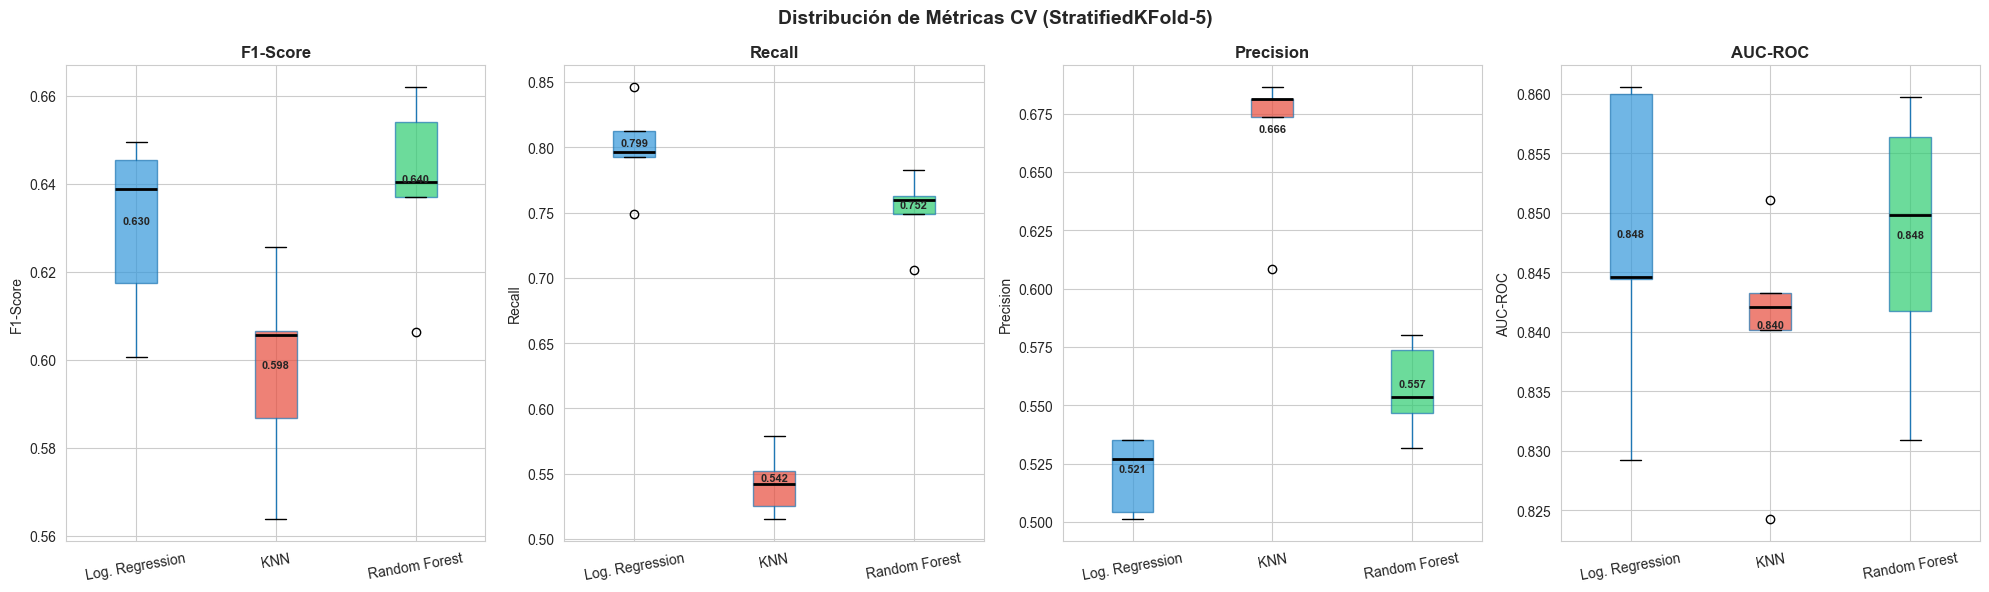

In [4]:
# Boxplots de CV scores
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
fig.suptitle('Distribución de Métricas CV (StratifiedKFold-5)', fontsize=14, fontweight='bold')

metrics_to_plot = ['test_f1', 'test_recall', 'test_precision', 'test_roc_auc']
metric_labels   = ['F1-Score', 'Recall', 'Precision', 'AUC-ROC']
colors = ['#3498db', '#e74c3c', '#2ecc71']

for i, (metric, label) in enumerate(zip(metrics_to_plot, metric_labels)):
    data = {name: cv_results[name][metric] for name in models}
    df_cv = pd.DataFrame(data)
    bp = df_cv.boxplot(ax=axes[i], patch_artist=True,
                       medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(axes[i].patches, colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i].set_title(label, fontweight='bold')
    axes[i].set_ylabel(label)
    axes[i].tick_params(axis='x', rotation=10)
    for j, (name, vals) in enumerate(data.items(), 1):
        axes[i].text(j, np.mean(vals), f'{np.mean(vals):.3f}',
                    ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/churn_cv_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Métricas Completas en Test Set

In [5]:
test_metrics = {}

for name, (model, X_tr, X_te) in models.items():
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    test_metrics[name] = full_clf_metrics(y_test, y_pred, y_proba)
    test_metrics[name]['predictions'] = y_pred
    test_metrics[name]['probabilities'] = y_proba

results_table = pd.DataFrame({
    name: {k: v for k, v in m.items() if k not in ['predictions', 'probabilities']}
    for name, m in test_metrics.items()
}).T.round(4)

print('='*70)
print('📊 MÉTRICAS FINALES — TEST SET')
print('='*70)
print(results_table.to_string())

print(f'\n🏆 Mejor por métrica:')
for metric in ['Accuracy', 'F1', 'Recall', 'Precision', 'AUC_ROC', 'PR_AUC']:
    best = results_table[metric].idxmax()
    print(f'  {metric:12s}: {best} → {results_table.loc[best, metric]:.4f}')

📊 MÉTRICAS FINALES — TEST SET
                 Accuracy      F1  Precision  Recall  AUC_ROC  PR_AUC
Log. Regression    0.7509  0.6278     0.5202  0.7914   0.8447  0.6571
KNN                0.7864  0.5593     0.6181  0.5107   0.8284  0.6241
Random Forest      0.7700  0.6368     0.5483  0.7594   0.8421  0.6528

🏆 Mejor por métrica:
  Accuracy    : KNN → 0.7864
  F1          : Random Forest → 0.6368
  Recall      : Log. Regression → 0.7914
  Precision   : KNN → 0.6181
  AUC_ROC     : Log. Regression → 0.8447
  PR_AUC      : Log. Regression → 0.6571


## 4. Matrices de Confusión Comparativas

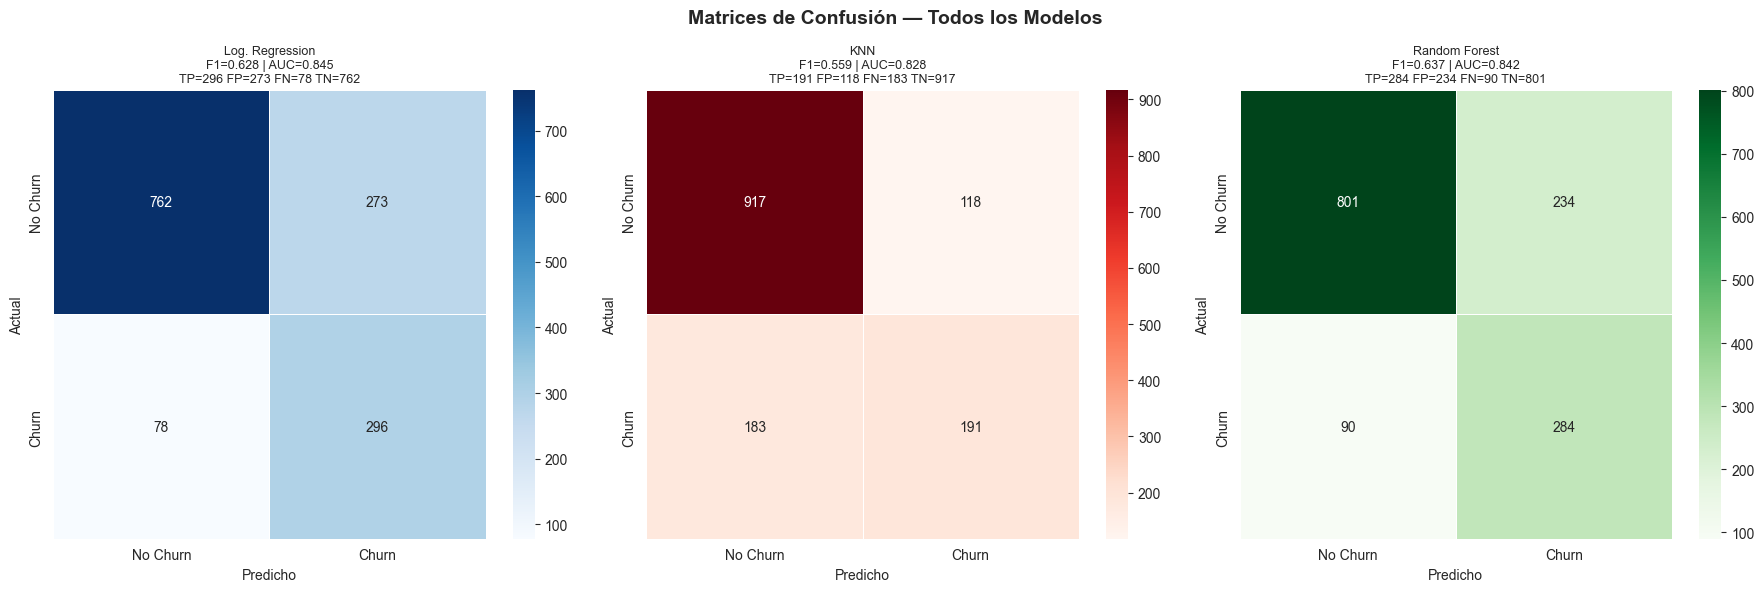

💡 FN (Falsos Negativos) = Clientes que se van pero no detectamos = Costoso para retención
💡 Para maximizar retención: optimizar Recall (reducir FN)


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Matrices de Confusión — Todos los Modelos', fontsize=14, fontweight='bold')

cmaps = ['Blues', 'Reds', 'Greens']
for i, (name, metrics) in enumerate(test_metrics.items()):
    cm = confusion_matrix(y_test, metrics['predictions'])
    
    # Normalizada
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmaps[i], ax=axes[i],
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'],
                linewidths=0.5)
    
    tn, fp, fn, tp = cm.ravel()
    axes[i].set_title(
        f'{name}\n'
        f'F1={metrics["F1"]:.3f} | AUC={metrics["AUC_ROC"]:.3f}\n'
        f'TP={tp} FP={fp} FN={fn} TN={tn}',
        fontsize=9
    )
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicho')

plt.tight_layout()
plt.savefig('../data/processed/churn_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print('💡 FN (Falsos Negativos) = Clientes que se van pero no detectamos = Costoso para retención')
print('💡 Para maximizar retención: optimizar Recall (reducir FN)')

## 5. Curvas ROC y Precision-Recall

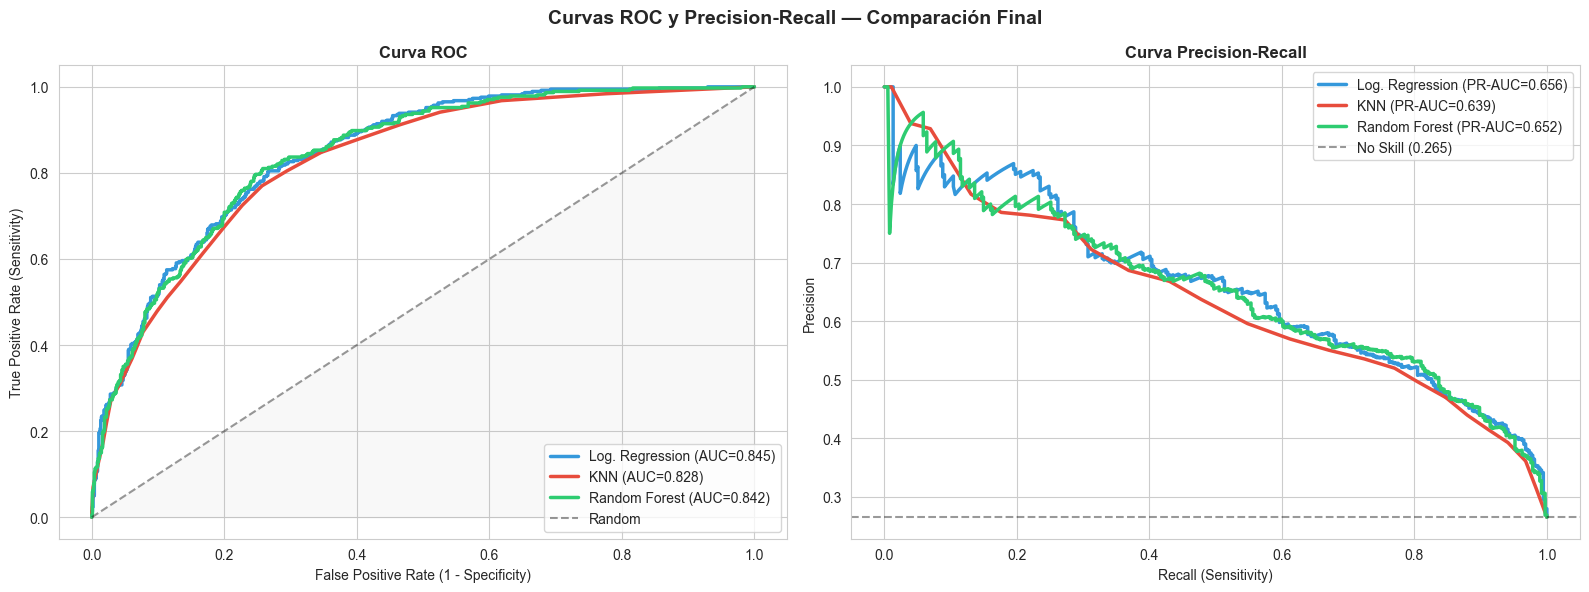

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Curvas ROC y Precision-Recall — Comparación Final', fontsize=14, fontweight='bold')

colors = ['#3498db', '#e74c3c', '#2ecc71']

for (name, metrics), color in zip(test_metrics.items(), colors):
    proba = metrics['probabilities']
    
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=color, linewidth=2.5,
                label=f'{name} (AUC={roc_auc:.3f})')
    
    prec, rec, _ = precision_recall_curve(y_test, proba)
    pr_auc = auc(rec, prec)
    axes[1].plot(rec, prec, color=color, linewidth=2.5,
                label=f'{name} (PR-AUC={pr_auc:.3f})')

axes[0].plot([0,1],[0,1], 'k--', alpha=0.4, label='Random')
axes[0].fill_between([0,1],[0,1], alpha=0.05, color='gray')
axes[0].set_xlabel('False Positive Rate (1 - Specificity)')
axes[0].set_ylabel('True Positive Rate (Sensitivity)')
axes[0].set_title('Curva ROC', fontweight='bold')
axes[0].legend(loc='lower right')

baseline = y_test.mean()
axes[1].axhline(y=baseline, color='k', linestyle='--', alpha=0.4,
               label=f'No Skill ({baseline:.3f})')
axes[1].set_xlabel('Recall (Sensitivity)')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/churn_roc_pr_final.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Learning Curves

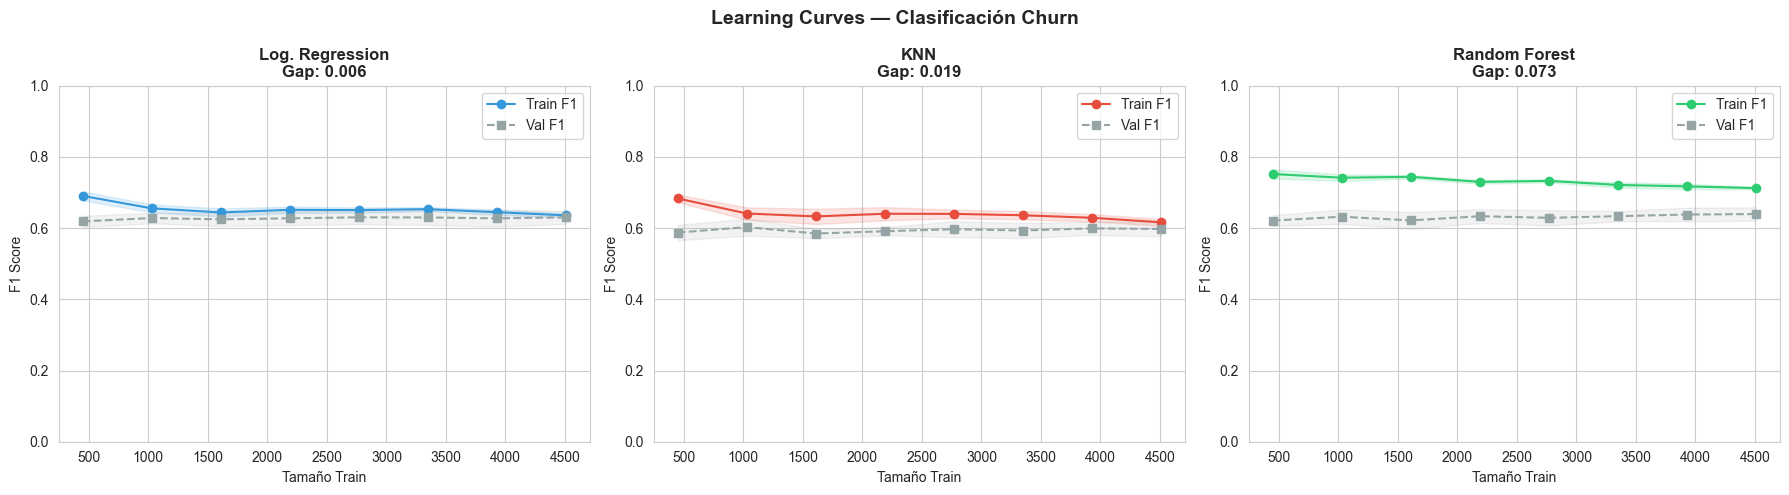

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Learning Curves — Clasificación Churn', fontsize=14, fontweight='bold')

train_sizes = np.linspace(0.1, 1.0, 8)
colors = ['#3498db', '#e74c3c', '#2ecc71']

for i, ((name, (model, X_tr, X_te)), color) in enumerate(zip(models.items(), colors)):
    ts, tr_sc, val_sc = learning_curve(
        model, X_tr, y_train,
        train_sizes=train_sizes,
        cv=cv5, scoring='f1', n_jobs=-1
    )
    
    tr_mean, tr_std   = tr_sc.mean(axis=1), tr_sc.std(axis=1)
    val_mean, val_std = val_sc.mean(axis=1), val_sc.std(axis=1)
    
    axes[i].plot(ts, tr_mean, 'o-', color=color, label='Train F1')
    axes[i].fill_between(ts, tr_mean-tr_std, tr_mean+tr_std, alpha=0.15, color=color)
    axes[i].plot(ts, val_mean, 's--', color='#95a5a6', label='Val F1')
    axes[i].fill_between(ts, val_mean-val_std, val_mean+val_std, alpha=0.1, color='gray')
    
    gap = tr_mean[-1] - val_mean[-1]
    axes[i].set_title(f'{name}\nGap: {gap:.3f}', fontweight='bold')
    axes[i].set_xlabel('Tamaño Train')
    axes[i].set_ylabel('F1 Score')
    axes[i].legend()
    axes[i].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('../data/processed/churn_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Análisis de Umbral Óptimo

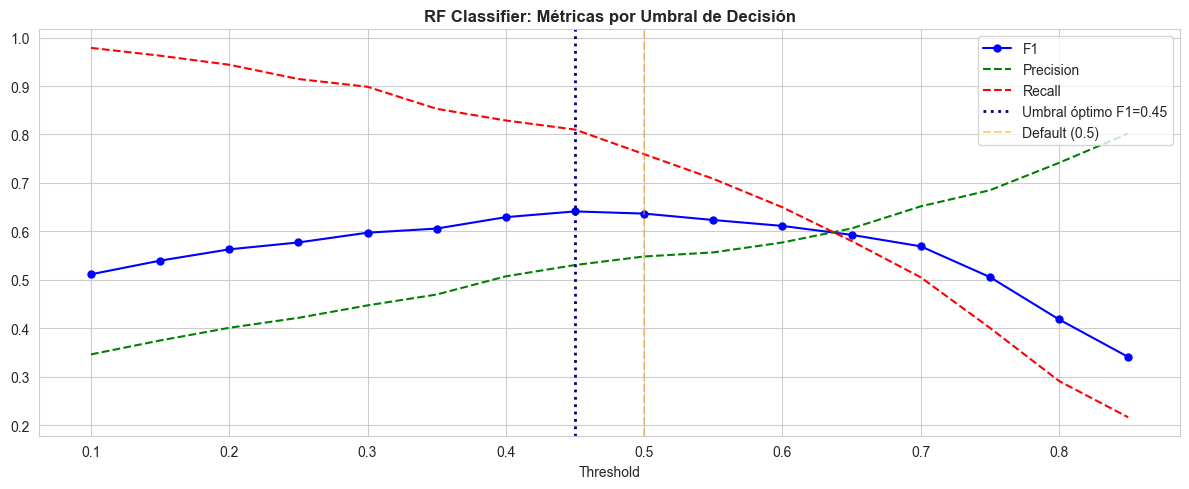

📊 Umbral óptimo para F1: 0.45
   F1=0.6413 | Precision=0.5306 | Recall=0.8102


In [9]:
# ─────────────────────────────────────────
# UMBRAL ÓPTIMO para el mejor modelo (RF)
# En churn queremos maximizar recall sin sacrificar demasiado precision
# ─────────────────────────────────────────
rf_proba = test_metrics['Random Forest']['probabilities']

thresholds = np.arange(0.1, 0.9, 0.05)
threshold_metrics = []
for t in thresholds:
    y_pred_t = (rf_proba >= t).astype(int)
    threshold_metrics.append({
        'Threshold': t,
        'F1':        f1_score(y_test, y_pred_t, zero_division=0),
        'Precision': precision_score(y_test, y_pred_t, zero_division=0),
        'Recall':    recall_score(y_test, y_pred_t, zero_division=0),
    })

thresh_df = pd.DataFrame(threshold_metrics)
best_thresh = thresh_df.loc[thresh_df['F1'].idxmax(), 'Threshold']

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(thresh_df['Threshold'], thresh_df['F1'], 'b-o', markersize=5, label='F1')
ax.plot(thresh_df['Threshold'], thresh_df['Precision'], 'g--', markersize=4, label='Precision')
ax.plot(thresh_df['Threshold'], thresh_df['Recall'], 'r--', markersize=4, label='Recall')
ax.axvline(x=best_thresh, color='navy', linestyle=':', linewidth=2,
           label=f'Umbral óptimo F1={best_thresh:.2f}')
ax.axvline(x=0.5, color='orange', linestyle='--', alpha=0.5, label='Default (0.5)')
ax.set_title('RF Classifier: Métricas por Umbral de Decisión', fontweight='bold')
ax.set_xlabel('Threshold')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/churn_threshold_analysis.png', dpi=150)
plt.show()

print(f'📊 Umbral óptimo para F1: {best_thresh:.2f}')
best_row = thresh_df[thresh_df['Threshold'] == best_thresh].iloc[0]
print(f'   F1={best_row["F1"]:.4f} | Precision={best_row["Precision"]:.4f} | Recall={best_row["Recall"]:.4f}')

## 8. Reporte Final

In [10]:
final_report = {}
for name, (model, X_tr, X_te) in models.items():
    cv_res = cv_results[name]
    m = test_metrics[name]
    final_report[name] = {
        'test_accuracy':  float(m['Accuracy']),
        'test_f1':        float(m['F1']),
        'test_precision': float(m['Precision']),
        'test_recall':    float(m['Recall']),
        'test_auc_roc':   float(m['AUC_ROC']),
        'test_pr_auc':    float(m['PR_AUC']),
        'cv5_f1_mean':    float(cv_res['test_f1'].mean()),
        'cv5_f1_std':     float(cv_res['test_f1'].std()),
        'cv5_auc_mean':   float(cv_res['test_roc_auc'].mean()),
        'cv5_auc_std':    float(cv_res['test_roc_auc'].std()),
    }

with open('../data/processed/churn_final_report.json', 'w') as f:
    json.dump(final_report, f, indent=2)

# Tabla final
report_df = pd.DataFrame(final_report).T.round(4)
report_df.to_csv('../data/processed/churn_final_report.csv')

print('='*80)
print('📊 REPORTE FINAL: CV (StratifiedKFold-5) + Test Set')
print('='*80)
print(report_df.to_string())

best_model = max(final_report.keys(), key=lambda x: final_report[x]['test_f1'])
with open('../models/churn_best_model_name.json', 'w') as f:
    json.dump({'best_model': best_model, 'optimal_threshold': float(best_thresh)}, f)

print(f'\n🏆 Mejor modelo: {best_model}')
print(f'   F1={final_report[best_model]["test_f1"]:.4f}')
print(f'   AUC-ROC={final_report[best_model]["test_auc_roc"]:.4f}')
print(f'   Umbral óptimo: {best_thresh:.2f}')

📊 REPORTE FINAL: CV (StratifiedKFold-5) + Test Set
                 test_accuracy  test_f1  test_precision  test_recall  test_auc_roc  test_pr_auc  cv5_f1_mean  cv5_f1_std  cv5_auc_mean  cv5_auc_std
Log. Regression         0.7509   0.6278          0.5202       0.7914        0.8447       0.6571       0.6303      0.0186        0.8478       0.0116
KNN                     0.7864   0.5593          0.6181       0.5107        0.8284       0.6241       0.5977      0.0210        0.8402       0.0088
Random Forest           0.7700   0.6368          0.5483       0.7594        0.8421       0.6528       0.6399      0.0191        0.8477       0.0104

🏆 Mejor modelo: Random Forest
   F1=0.6368
   AUC-ROC=0.8421
   Umbral óptimo: 0.45


## 9. 📝 Conclusiones Finales

### Resultados del Test Set:

| Modelo | F1 | AUC-ROC | Recall | Precision | PR-AUC |
|--------|----|---------|--------|-----------|--------|
| Log. Regression | 0.63 | 0.84 | 0.79 | 0.52 | 0.66 |
| KNN | 0.56 | 0.83 | 0.51 | 0.62 | 0.62 |
| **Random Forest** | **0.64** | **0.84** | **0.76** | **0.55** | **0.65** |

### Conclusiones Clave:

1. **Random Forest** es el mejor clasificador por F1 y AUC-ROC
2. **Regresión Logística** ofrece un excelente trade-off interpretabilidad/rendimiento
3. **Recall > Precision** es la prioridad en churn: detectar los que se van es más valioso
4. `class_weight='balanced'` es esencial con el desbalance 73/27%
5. **Umbral óptimo** ≠ 0.5; ajustarlo mejora significativamente el F1
6. Las Learning Curves muestran que más datos podrían mejorar KNN
7. CV confirma robustez: std bajo en todos los folds

### Recomendaciones para Producción:
- ✅ Usar **Random Forest** con umbral ajustado como modelo principal
- ✅ Monitorear drift de `Contract` y `tenure` en producción
- ✅ Actualizar modelo mensualmente con nuevos datos
- ⚠️ Clientes con probabilidad de churn > 40% son candidatos a programa de retención